# Atividade 5 — Gráficos e IDH (17/09/2026)

Parte 1 usa os dados que já construímos nas atividades 2, 3 e 4 (afazeres domésticos, formação acadêmica e população por UF) e faz os gráficos pedidos. Parte 2 abre a tabela de IDH por estado (Tabela4.csv), limpa, transforma para o formato longo e plota a evolução.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Parte 1 - Gráficos

### Atividade 2 — horas de afazeres domésticos por região

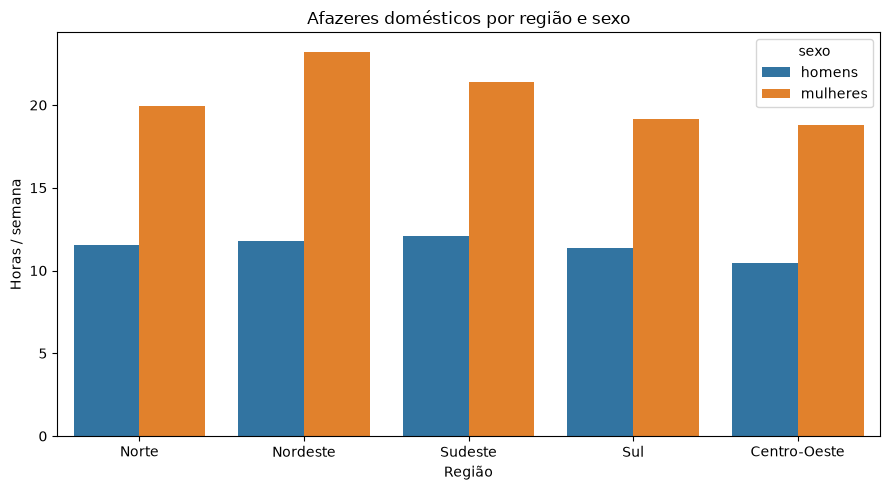

In [2]:
indicador_1 = pd.DataFrame({
    "uf_regiao": ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"],
    "homem_branca": [11.588653, 11.723907, 11.933522, 11.546629, 10.546799],
    "homem_preta_parda": [11.514646, 11.848436, 12.180843, 11.159487, 10.332059],
    "mulher_branca": [19.295780, 22.744666, 20.732969, 19.012969, 18.220683],
    "mulher_preta_parda": [20.534188, 23.716716, 21.990431, 19.338734, 19.331040],
})

regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2

reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()

### Atividade 3 — formação acadêmica no Brasil, por área e sexo

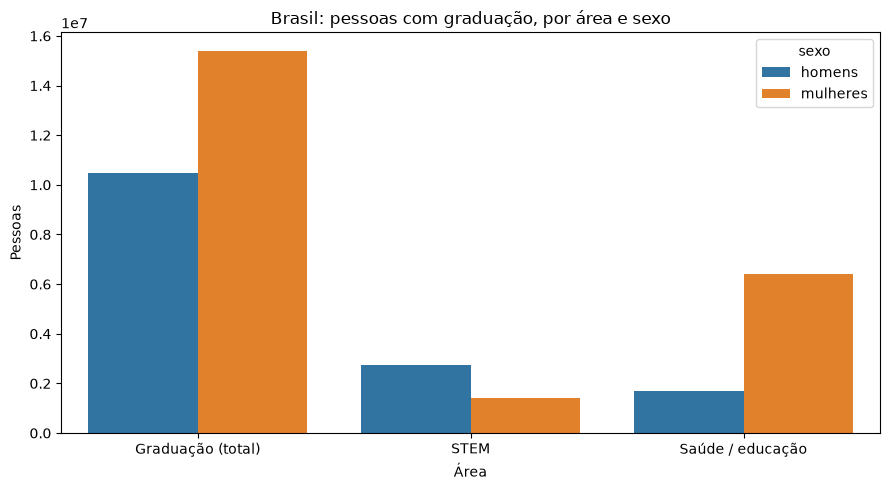

In [3]:
brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [10478534, 2750422, 1677985],
        "mulheres": [15375757, 1398619, 6401723],
    }
)

brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
plt.tight_layout()
plt.show()

### Atividade 4 — população por UF (2022)

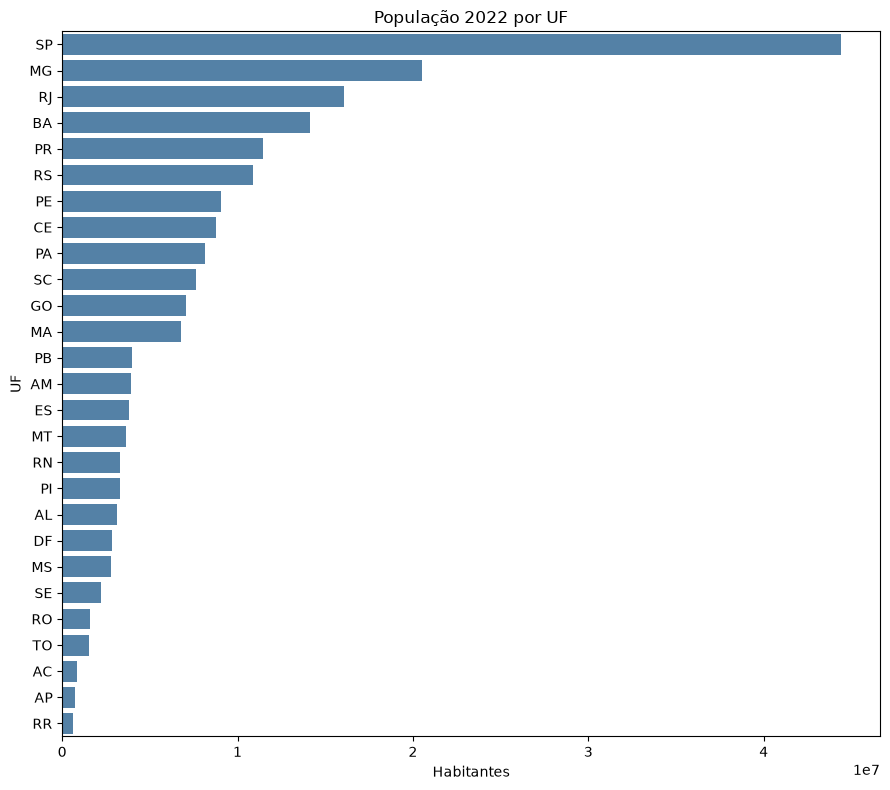

In [4]:
pop_estado = pd.read_csv(
    "populacao_por_estado.csv",
    sep=";",
    index_col=0,
)

ordem = pop_estado.sort_values("populacao_2022", ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=ordem, y="UF", x="populacao_2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()

## Parte 2 - IDH

### 1. Abrir o CSV

Tabela4.csv — IDHM por UF de 1991 a 2024. A primeira linha do arquivo é só um título solto (não é o cabeçalho), e o texto está com problema de acentuação (foi salvo em UTF-8 duas vezes).

In [5]:
path_idh = "Tabela4.csv"
df = pd.read_csv(path_idh, skiprows=1)
df.head()

,Sigla,CÃ³digo,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,402,517,663,705,709,719,719,723,711,731,738,736,702,732,"0,74",754
1,AL,27,Alagoas,"0,37",471,631,657,653,"0,67",669,"0,68",682,694,693,694,691,722,739,746
2,AM,13,Amazonas,"0,43",515,674,706,717,"0,72",724,723,743,732,739,725,"0,7",757,764,767
3,AP,16,AmapÃ¡,472,577,708,709,735,726,728,732,731,737,732,707,681,743,767,759
4,BA,29,Bahia,386,512,"0,66",684,686,"0,7",708,708,715,714,723,726,698,734,"0,74",759


### 2. Limpar colunas vazias, acentuação e os valores de IDH

Os anos vieram com formatos diferentes: às vezes `"0,74"` (vírgula decimal), às vezes `705` (sem o `0,` na frente, mas representando `0,705`).

In [6]:
df = df.dropna(axis=1, how="all")

def corrigir_texto(valor):
    if isinstance(valor, str):
        try:
            return valor.encode("latin1").decode("utf-8")
        except (UnicodeDecodeError, UnicodeEncodeError):
            return valor
    return valor

df.columns = [corrigir_texto(c) for c in df.columns]
df["Sigla"] = df["Sigla"].apply(corrigir_texto)
df["Estado"] = df["Estado"].apply(corrigir_texto)

def corrigir_idh(valor):
    texto = str(valor).strip()
    if "," in texto:
        return float(texto.replace(",", "."))
    return int(texto) / 1000

anos_bruto = [c for c in df.columns if str(c).isdigit()]
for coluna in anos_bruto:
    df[coluna] = df[coluna].apply(corrigir_idh)

df

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759
5,CE,23,Ceará,0.405,0.541,0.682,0.709,0.712,0.717,0.723,0.727,0.737,0.746,0.754,0.753,0.740,0.759,0.773,0.773
6,DF,53,Distrito Federal,0.616,0.725,0.824,0.824,0.834,0.834,0.833,0.842,0.842,0.845,0.860,0.837,0.823,0.867,0.870,0.866
7,ES,32,Espírito Santo,0.505,0.640,0.740,0.747,0.755,0.763,0.766,0.766,0.769,0.776,0.780,0.773,0.754,0.782,0.803,0.804
8,GO,52,Goiás,0.487,0.615,0.735,0.744,0.753,0.759,0.758,0.765,0.770,0.776,0.780,0.777,0.755,0.797,0.809,0.815
9,MA,21,Maranhão,0.357,0.476,0.639,0.669,0.682,0.683,0.690,0.698,0.704,0.706,0.715,0.715,0.701,0.730,0.740,0.745


### 3. Formato longo (`melt`)

In [7]:
anos = [c for c in df.columns if str(c).isdigit()]
variaveis = [c for c in df.columns if c not in anos]

df_longo = df.melt(
    id_vars=variaveis,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo

,Sigla,Código,Estado,Ano,IDH
0,AC,12,Acre,1991,0.402
1,AL,27,Alagoas,1991,0.370
2,AM,13,Amazonas,1991,0.430
3,AP,16,Amapá,1991,0.472
4,BA,29,Bahia,1991,0.386
...,...,...,...,...,...
427,RS,43,Rio Grande do Sul,2024,0.818
428,SC,42,Santa Catarina,2024,0.833
429,SE,28,Sergipe,2024,0.761
430,SP,35,São Paulo,2024,0.838


### 4. Evolução do IDH de cada estado

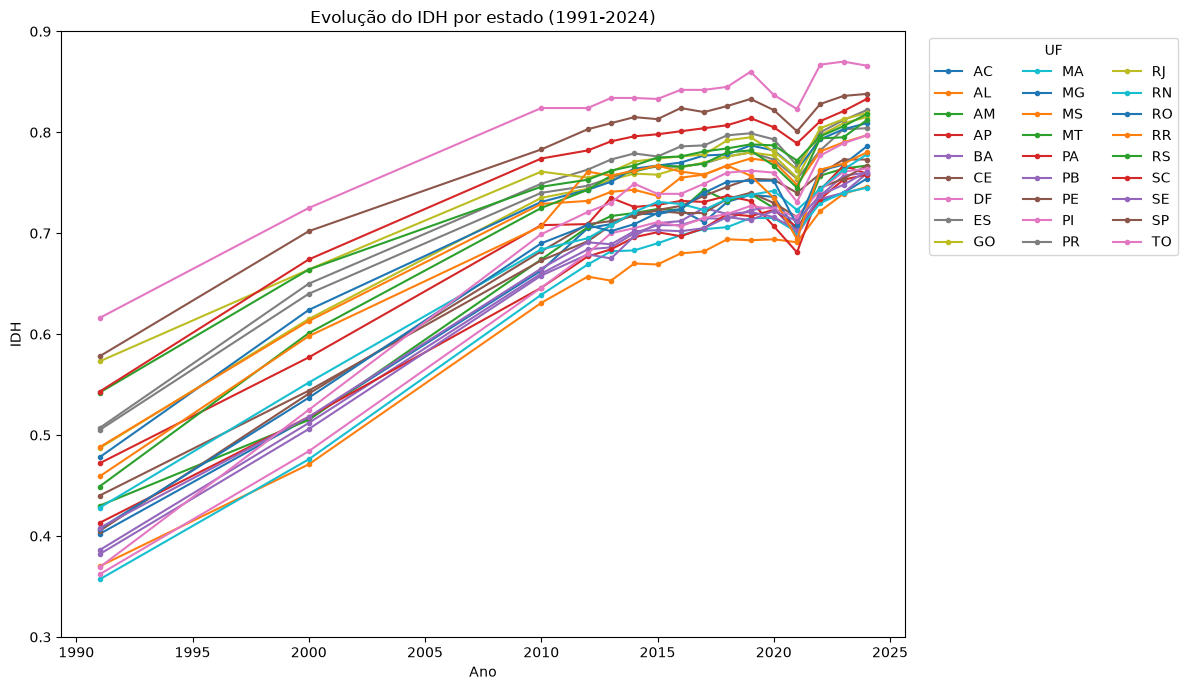

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991-2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()

### 5. IDH de Minas Gerais

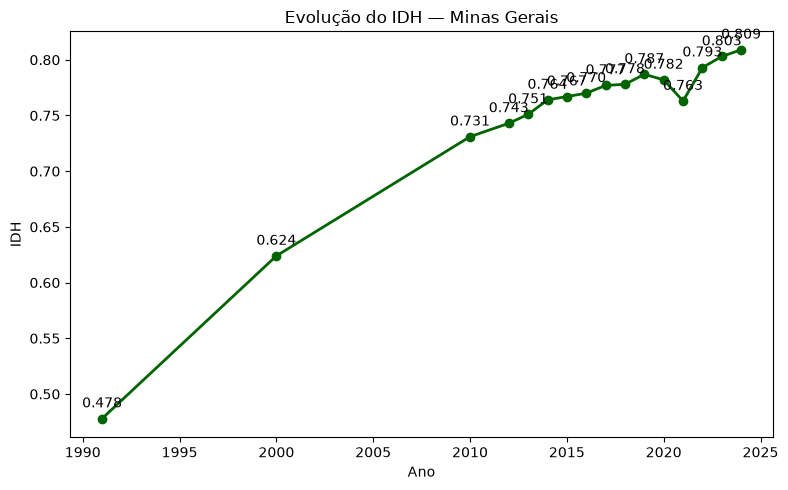

,Sigla,Código,Estado,Ano,IDH
10,MG,31,Minas Gerais,1991,0.478
37,MG,31,Minas Gerais,2000,0.624
64,MG,31,Minas Gerais,2010,0.731
91,MG,31,Minas Gerais,2012,0.743
118,MG,31,Minas Gerais,2013,0.751
145,MG,31,Minas Gerais,2014,0.764
172,MG,31,Minas Gerais,2015,0.767
199,MG,31,Minas Gerais,2016,0.770
226,MG,31,Minas Gerais,2017,0.777
253,MG,31,Minas Gerais,2018,0.778


In [9]:
mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mg["Ano"], mg["IDH"], marker="o", linewidth=2, color="darkgreen")
ax.set_title("Evolução do IDH — Minas Gerais")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
for x, y in zip(mg["Ano"], mg["IDH"]):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout()
plt.show()
mg